### QQP with Mamba

In [2]:
from __future__ import annotations
from typing import Dict, Any

from pathlib import Path

from qqp_task import QQPTask
from src.train_utils.trainer import Trainer

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory for consistent configuration.

In [3]:
from src.utils.block_factory import make_mamba_block_cfg_ctor

In [4]:
from src.utils.common import device_auto

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "qqp" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 256,
    "data_loader_kwargs": {
        "num_workers": 0,
        "pin_memory": False,
        "persistent_workers": False,
        "seed": 42,
        "val_ratio": 0.1,
        "test_ratio": 0.1,
        "lowercase": True,
        "max_len": 64,
        "max_vocab": 50_000,
        "min_freq": 2,
    },

    "epochs": 100,
    "lr": 1e-4,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/qqp_mamba_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 1,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # Mamba-specific parameters
    "d_state": 16,
    "expand_factor": 2,
    "d_conv": 4,
    "use_external_mlp": True,

    # QQP specific
    "max_len": 64,
}

args["block_cfg_ctor"] = make_mamba_block_cfg_ctor(
   **args,
)

args = device_auto(args)

Using MPS


### Training
With the configuration set up, we can now instantiate the `QQPTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [5]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = QQPTask()

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 48
Val metrics: {'loss': 0.4872248948497473, 'time_s': 8.68691463900177, 'acc': 0.7874118956349697}


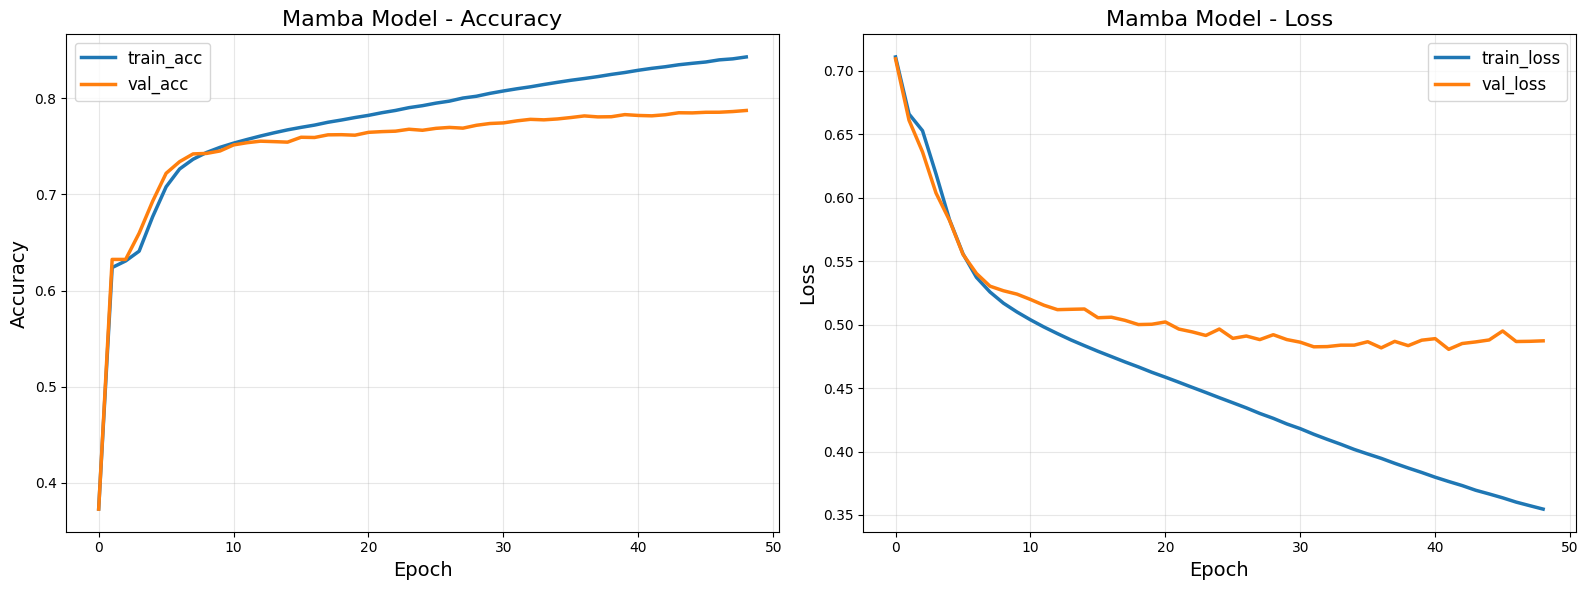


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: MambaCoreAdapter
Number of Blocks: 1

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:              6,535,811
Trainable parameters:          6,535,811
Non-trainable parameters:              0
Model size (MB):                   24.93

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
embedding                      Embedding                       6,318,976
blocks                         ModuleLi

In [7]:
from src.utils.common import print_model_details
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=QQPTask(),
)

history = trainer.history

plot_history(history, model_name="Mamba")

print_model_details(model=trainer.model)

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>, q2]; y ∈ {0,1}
Using embedding layer with vocab_size=49367
Loaded checkpoint from epoch 48
Val metrics: {'loss': 0.4872248948497473, 'time_s': 8.68691463900177, 'acc': 0.7874118956349697}
QQP Loaders Created:
  CSV: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/qqp/data/questions.csv
  Train: 323481 samples, 1263 batches
  Val:   40435 samples, 158 batches
  Test:  40435 samples, 158 batches
  Seed: 42 | val_ratio=0.1 | test_ratio=0.1
  max_len per question: 64 tokens
  vocab_size: 49367 (max_vocab=50000, min_freq=2)
  x shape: (max_len * 2 + 1,) = (129,) concatenated [q1, <seq>

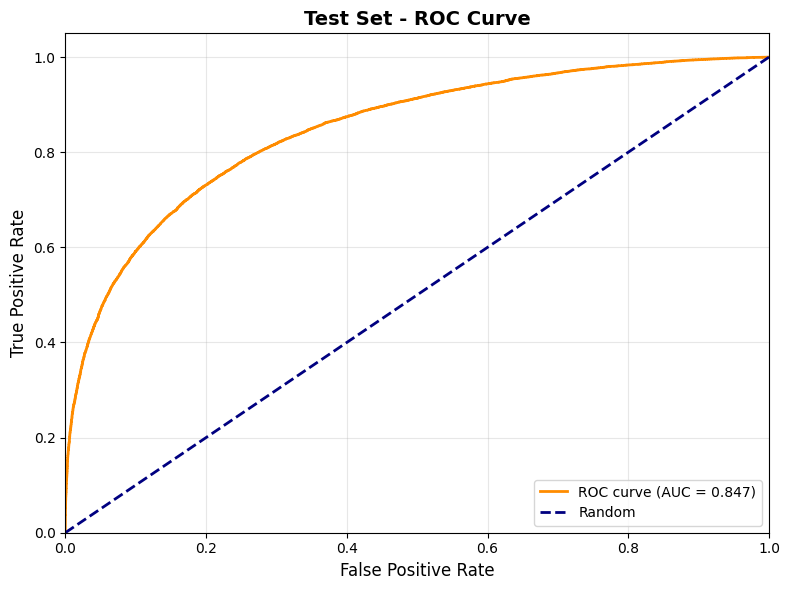

2. Precision-Recall Curve...


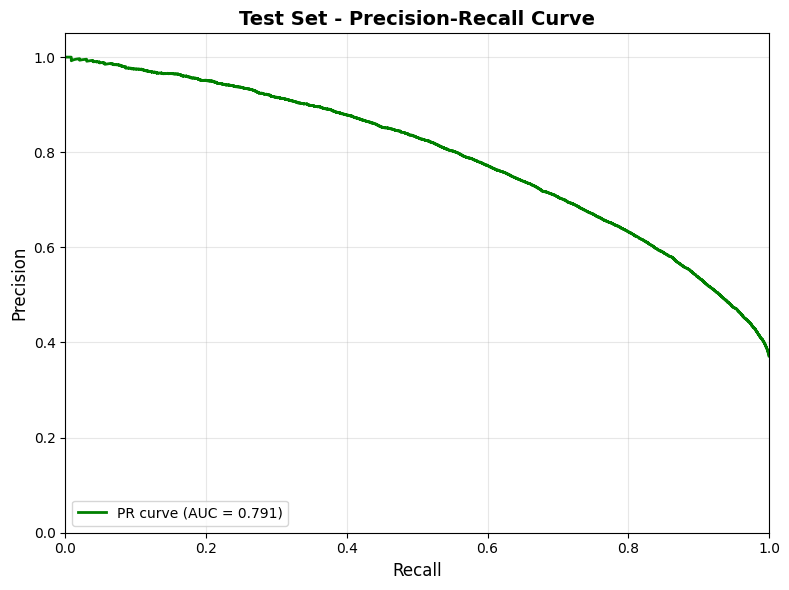

3. Confusion Matrix...


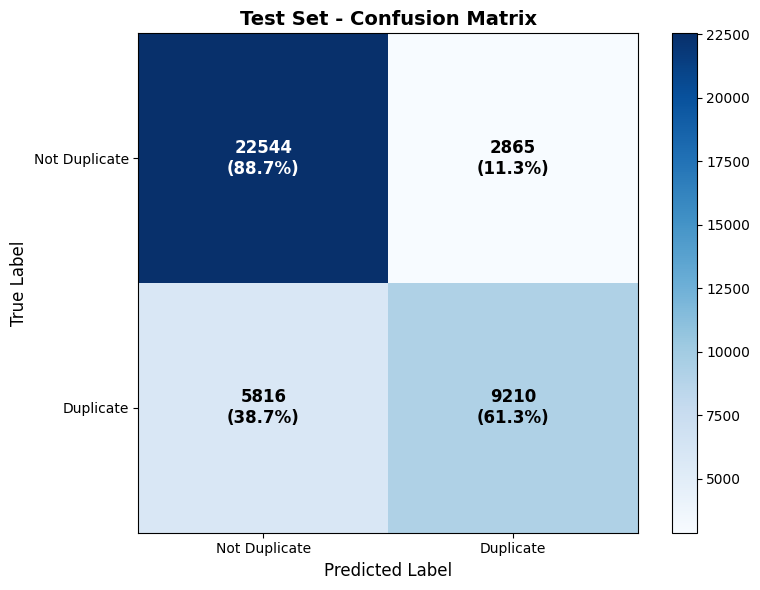

4. Threshold Analysis...


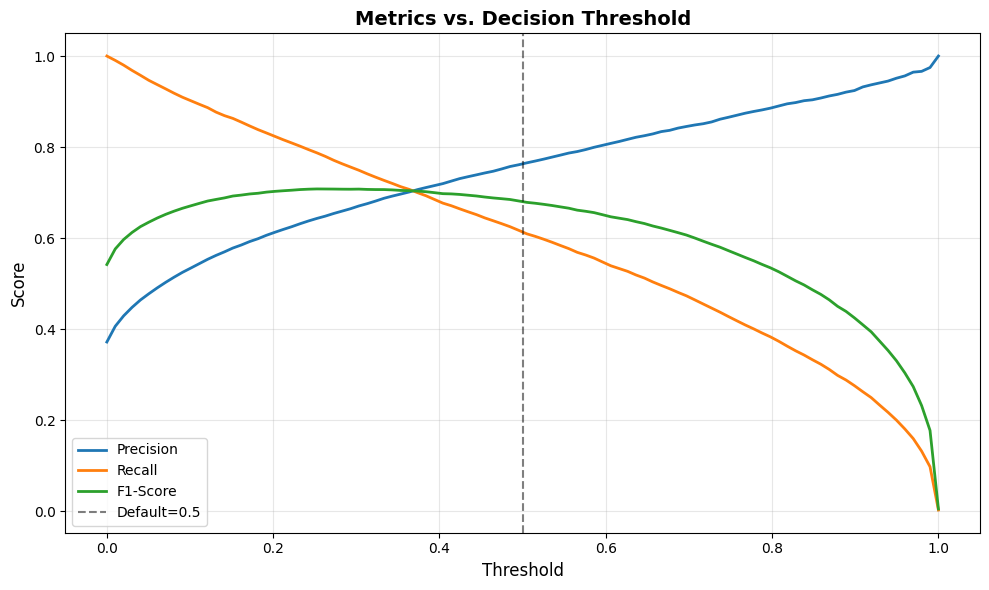

5. Metrics Summary...


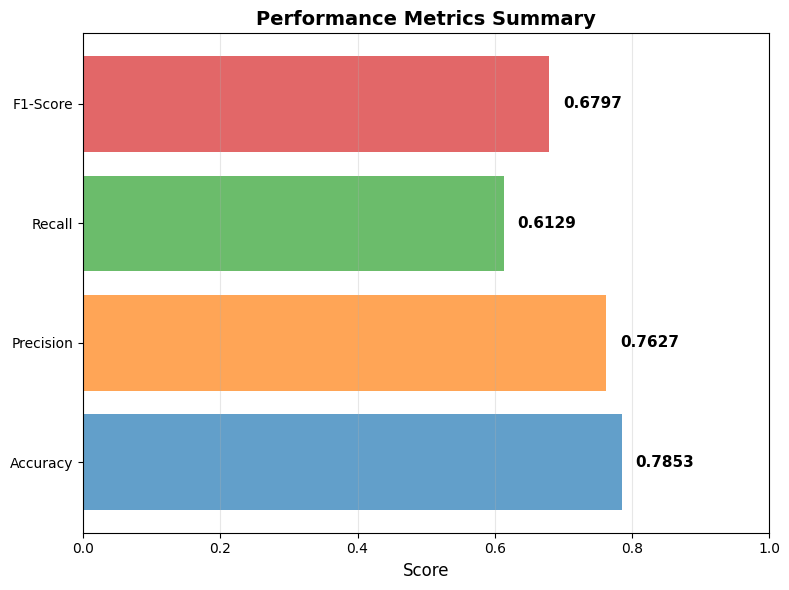

6. Class Distribution...


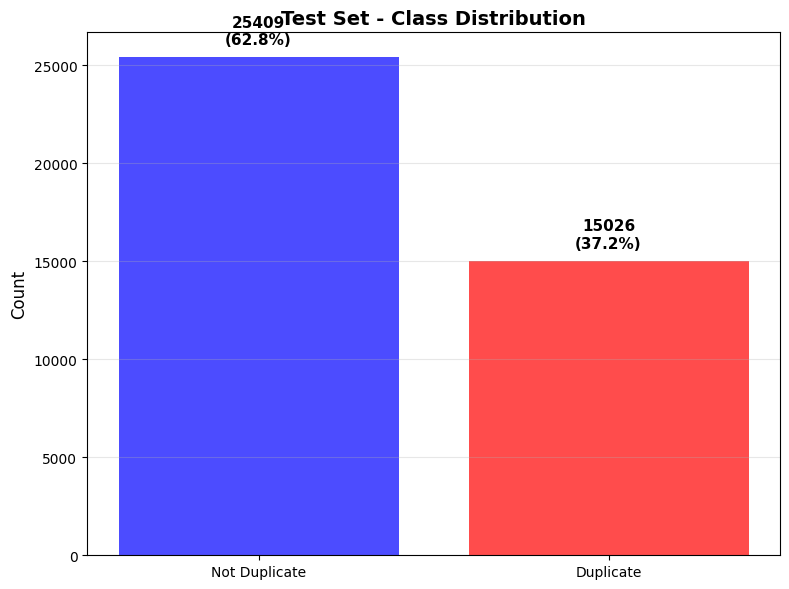


All visualizations generated!


In [8]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=QQPTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=2,
    use_test_set=True,
    additional_metrics=['precision', 'recall', 'pr_auc', 'roc_auc', 'f1_score'],
)

### Changes in dataset length

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/qqp_mamba_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=QQPTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="Mamba")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=QQPTask(),
        best_model_path=best_path,
        num_classes=2,
        use_test_set=True,
        additional_metrics=['precision', 'recall', 'pr_auc', 'roc_auc', 'f1_score']
    )